# Machine Learning-Based Detection and Classification of Cyber Attacks in a Homelab SOC Environment
**Author:** Daniel Cruz  
**Course:** Data Science / Project Month  
**School:** Ocean County Vocational — Data Science Project Month

---
## Overview
This notebook applies five machine learning algorithms to 245,078 log events exported from a homelab Security Operations Center (SOC). The goal is to detect and classify cyber attacks using real data captured from tools including Wazuh, Suricata, Graylog, and Grafana.

**Algorithms Used:**
1. Linear Regression (Required)
2. Logistic Regression (Required)
3. K-Means Clustering (Required)
4. Random Forest
5. Decision Tree

## Step 0 — Install Dependencies

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn -q

## Step 1 — Upload Dataset
Upload your `All-Messages-search-resultnew.csv` file from Graylog.

In [ ]:
from google.colab import files
import os

print("Upload your CSV file (All-Messages-search-resultnew.csv)")
uploaded = files.upload()

CSV_PATH = list(uploaded.keys())[0]
print(f"\n[+] File uploaded: {CSV_PATH}")

# Create figures directory
os.makedirs('figures', exist_ok=True)

Upload your CSV file (All-Messages-search-resultnew.csv)


Saving All-Messages-search-resultnew11.csv to All-Messages-search-resultnew11.csv

[+] File uploaded: All-Messages-search-resultnew11.csv


## Step 2 — Data Processing
Load, clean, and engineer features from the raw Graylog log export.

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Known attack source IPs from the homelab
ATTACK_IPS = ['192.168.1.50', '192.168.1.157']

def load_data(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    print(f"[+] Loaded {len(df):,} rows, {len(df.columns)} columns")
    return df

def parse_timestamps(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df['timestamp'] = df['timestamp'].dt.tz_localize(None)
    df['hour'] = df['timestamp'].dt.hour
    df['minute'] = df['timestamp'].dt.minute
    df['second'] = df['timestamp'].dt.second
    df['time_numeric'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()
    return df

def extract_src_ip(message):
    ufw = re.search(r'SRC=([\d.]+)', str(message))
    if ufw: return ufw.group(1)
    ssh = re.search(r'from ([\d.]+)', str(message))
    if ssh: return ssh.group(1)
    src = re.search(r'"src_ip":"([\d.]+)"', str(message))
    if src: return src.group(1)
    return None

def extract_dest_port(message):
    ufw = re.search(r'DPT=(\d+)', str(message))
    if ufw: return int(ufw.group(1))
    if 'sshd' in str(message) or 'ssh' in str(message).lower():
        port = re.search(r'port (\d+)', str(message))
        if port: return int(port.group(1))
    dest = re.search(r'"dest_port":(\d+)', str(message))
    if dest: return int(dest.group(1))
    return 0

def classify_event_type(row):
    app = str(row.get('application_name', ''))
    msg = str(row.get('message', ''))
    facility = str(row.get('facility', ''))
    if app == 'suricata':
        return 'suricata_alert' if '"event_type":"alert"' in msg else 'suricata_flow'
    elif app == 'sshd' or 'ssh' in app.lower():
        if any(x in msg for x in ['Failed', 'Invalid', 'authentication failure', 'Too many']):
            return 'ssh_failure'
        elif 'Accepted' in msg:
            return 'ssh_success'
        return 'ssh_other'
    elif app == 'kernel' and 'UFW BLOCK' in msg:
        return 'ufw_block'
    elif app == 'pihole-dns':
        return 'dns_query'
    elif facility == 'security/authorization':
        return 'auth_event'
    return 'other'

def label_attack(row):
    src_ip = str(row.get('src_ip_extracted', ''))
    msg = str(row.get('message', ''))
    event_type = str(row.get('event_type', ''))
    if src_ip in ATTACK_IPS: return 1
    if event_type == 'ssh_failure':
        if any(ip in msg for ip in ATTACK_IPS): return 1
        if any(x in msg for x in ['Too many authentication failures', 'maximum authentication attempts']): return 1
    if event_type == 'suricata_alert': return 1
    return 0

def engineer_features(df):
    print("[+] Extracting source IPs...")
    df['src_ip_extracted'] = df['message'].apply(extract_src_ip)
    print("[+] Extracting destination ports...")
    df['dest_port'] = df['message'].apply(extract_dest_port)
    print("[+] Classifying event types...")
    df['event_type'] = df.apply(classify_event_type, axis=1)
    print("[+] Labeling attacks...")
    df['is_attack'] = df.apply(label_attack, axis=1)
    print(f"[+] Attack events: {df['is_attack'].sum():,} / {len(df):,} total ({df['is_attack'].mean()*100:.1f}%)")
    return df

def encode_features(df):
    le_event = LabelEncoder()
    le_facility = LabelEncoder()
    le_source = LabelEncoder()
    df['event_type_encoded'] = le_event.fit_transform(df['event_type'].fillna('other'))
    df['facility_encoded'] = le_facility.fit_transform(df['facility'].fillna('unknown'))
    df['source_encoded'] = le_source.fit_transform(df['source'].fillna('unknown'))
    df['level'] = pd.to_numeric(df['level'], errors='coerce').fillna(0)
    df['gl2_accounted_message_size'] = pd.to_numeric(df['gl2_accounted_message_size'], errors='coerce').fillna(0)
    return df

def get_feature_matrix(df):
    features = ['hour','minute','second','time_numeric','event_type_encoded',
                'facility_encoded','source_encoded','level','gl2_accounted_message_size','dest_port']
    X = df[features].fillna(0)
    y = df['is_attack']
    return X, y

def compute_attack_volume_over_time(df):
    df['minute_bucket'] = df['timestamp'].dt.floor('1min')
    agg = df.groupby('minute_bucket').agg(
        total_events=('is_attack', 'count'),
        attack_events=('is_attack', 'sum')
    ).reset_index()
    agg['time_index'] = range(len(agg))
    return agg

# Run preprocessing
df = load_data(CSV_PATH)
df = parse_timestamps(df)
df = engineer_features(df)
df = encode_features(df)
X, y = get_feature_matrix(df)
agg = compute_attack_volume_over_time(df)

print(f"\n[+] Dataset Summary:")
print(f"    Total log events:  {len(df):,}")
print(f"    Attack events:     {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"    Normal events:     {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"    Time range:        {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"    Features:          {X.shape[1]}")

[+] Loaded 245,078 rows, 28 columns
[+] Extracting source IPs...
[+] Extracting destination ports...
[+] Classifying event types...
[+] Labeling attacks...
[+] Attack events: 1,251 / 245,078 total (0.5%)

[+] Dataset Summary:
    Total log events:  245,078
    Attack events:     1,251 (0.5%)
    Normal events:     243,827 (99.5%)
    Time range:        2026-05-11 01:24:10.369000 → 2026-05-11 02:53:25
    Features:          10


## Step 3 — Machine Learning Models

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

results = {}

### 3.1 Linear Regression
Predicts attack event volume over time. Independent variable = time index (minutes), dependent variable = attack count per minute.

In [ ]:
X_lr = agg[['time_index']].values
y_lr = agg['attack_events'].values

X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print(f"Coefficient (slope):  {lr_model.coef_[0]:.4f}")
print(f"Intercept:            {lr_model.intercept_:.4f}")
print(f"Mean Squared Error:   {lr_mse:.4f}")
print(f"R² Score:             {lr_r2:.4f}")
print(f"\nInterpretation: The negative R² ({lr_r2:.4f}) indicates attack events are not linearly")
print(f"predictable over time — attacks occur in sudden bursts, not gradual trends.")

results['linear_regression'] = {
    'model': lr_model, 'X_test': X_test, 'y_test': y_test,
    'y_pred': y_pred, 'r2': lr_r2, 'mse': lr_mse, 'agg': agg
}

Coefficient (slope):  0.3282
Intercept:            1.5059
Mean Squared Error:   179.6246
R² Score:             -3.7067

Interpretation: The negative R² (-3.7067) indicates attack events are not linearly
predictable over time — attacks occur in sudden bursts, not gradual trends.


### 3.2 Logistic Regression
Binary classification — attack (1) vs normal (0) — using log features.

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_s, y_train)
log_pred = log_model.predict(X_test_s)

log_acc = accuracy_score(y_test, log_pred)
print(f"Accuracy: {log_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, log_pred, target_names=['Normal', 'Attack']))

results['logistic_regression'] = {
    'model': log_model, 'X_test': X_test, 'y_test': y_test,
    'y_pred': log_pred, 'accuracy': log_acc, 'scaler': scaler
}

Accuracy: 99.68%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     48766
      Attack       0.84      0.45      0.59       250

    accuracy                           1.00     49016
   macro avg       0.92      0.73      0.79     49016
weighted avg       1.00      1.00      1.00     49016



### 3.3 K-Means Clustering
Unsupervised grouping into k=4 clusters matching the 4 attack types: SSH brute force, Nmap, DoS, Metasploit.

In [ ]:
scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X)

km_model = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = km_model.fit_predict(X_scaled)
df_clustered = df.copy()
df_clustered['cluster'] = clusters

print(f"Number of clusters: 4")
print(f"Inertia: {km_model.inertia_:.2f}")
print("\nCluster distribution:")
for i in range(4):
    cluster_df = df_clustered[df_clustered['cluster'] == i]
    attack_pct = cluster_df['is_attack'].mean() * 100
    top_event = cluster_df['event_type'].value_counts().index[0]
    print(f"  Cluster {i}: {len(cluster_df):,} events | {attack_pct:.1f}% attacks | dominant: {top_event}")

results['kmeans'] = {'model': km_model, 'clusters': clusters, 'df_clustered': df_clustered}

Number of clusters: 4
Inertia: 1307462.89

Cluster distribution:
  Cluster 0: 80,228 events | 0.0% attacks | dominant: dns_query
  Cluster 1: 88,270 events | 0.8% attacks | dominant: dns_query
  Cluster 2: 52,767 events | 0.3% attacks | dominant: suricata_flow
  Cluster 3: 23,813 events | 1.7% attacks | dominant: other


### 3.4 Random Forest
Ensemble classifier using 100 decision trees. Also provides feature importance scores.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Attack']))

feature_names = ['hour','minute','second','time_numeric','event_type','facility','source','level','message_size','dest_port']
importances = rf_model.feature_importances_
feat_imp = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
print("\nTop Feature Importances:")
for name, imp in feat_imp:
    print(f"  {name:<20} {imp:.4f}")

results['random_forest'] = {
    'model': rf_model, 'X_test': X_test, 'y_test': y_test,
    'y_pred': rf_pred, 'accuracy': rf_acc, 'feature_importances': feat_imp
}

Accuracy: 99.99%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     48766
      Attack       0.99      0.99      0.99       250

    accuracy                           1.00     49016
   macro avg       1.00      0.99      0.99     49016
weighted avg       1.00      1.00      1.00     49016


Top Feature Importances:
  event_type           0.3209
  source               0.1788
  message_size         0.1515
  dest_port            0.1403
  facility             0.0913
  level                0.0549
  time_numeric         0.0345
  minute               0.0164
  second               0.0109
  hour                 0.0005


### 3.5 Decision Tree
Interpretable classifier limited to depth=5. Shows exact rules used to classify attacks.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print(f"Accuracy: {dt_acc*100:.2f}%")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['Normal', 'Attack']))

results['decision_tree'] = {
    'model': dt_model, 'X_test': X_test, 'y_test': y_test,
    'y_pred': dt_pred, 'accuracy': dt_acc
}

Accuracy: 99.89%
Tree depth: 5
Number of leaves: 21

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     48766
      Attack       0.99      0.80      0.88       250

    accuracy                           1.00     49016
   macro avg       1.00      0.90      0.94     49016
weighted avg       1.00      1.00      1.00     49016



## Step 4 — Results Summary

In [ ]:
print("=" * 55)
print("  RESULTS SUMMARY")
print("=" * 55)
print(f"  Linear Regression R²:         {results['linear_regression']['r2']:.4f}")
print(f"  Logistic Regression Accuracy:  {results['logistic_regression']['accuracy']*100:.2f}%")
print(f"  Random Forest Accuracy:        {results['random_forest']['accuracy']*100:.2f}%")
print(f"  Decision Tree Accuracy:        {results['decision_tree']['accuracy']*100:.2f}%")
print(f"  K-Means Clusters:              4")
print("=" * 55)

  RESULTS SUMMARY
  Linear Regression R²:         -3.7067
  Logistic Regression Accuracy:  99.68%
  Random Forest Accuracy:        99.99%
  Decision Tree Accuracy:        99.89%
  K-Means Clusters:              4


## Step 5 — Visualizations
All 9 thesis figures generated inline and saved to `./figures/`

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Dark theme matching original
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

ATTACK_COLOR = '#f85149'
NORMAL_COLOR = '#3fb950'
ACCENT = '#58a6ff'

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f'figures/{name}.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    plt.close()
    print(f"[+] Saved figures/{name}.png")

print("[+] Plot settings configured. Run the cells below for each figure.")

[+] Plot settings configured. Run the cells below for each figure.


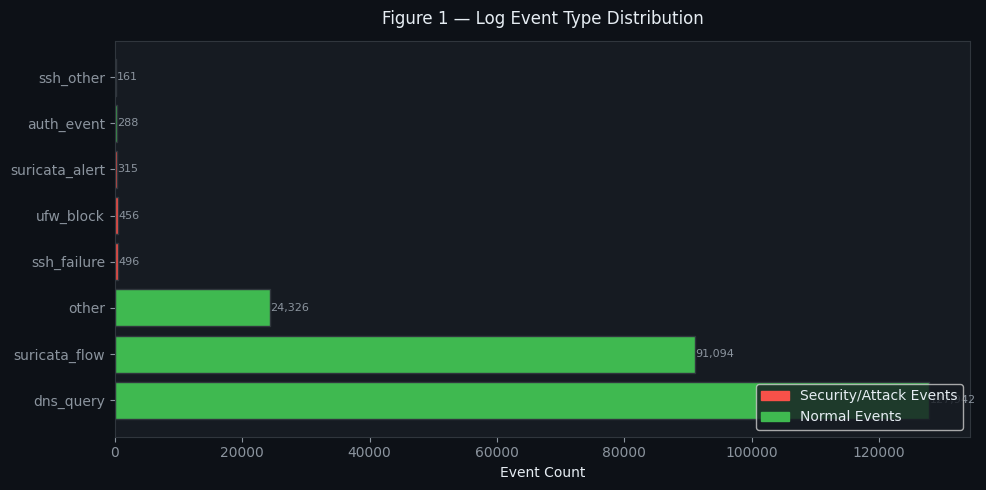

[+] Saved figures/fig1_event_distribution.png


In [ ]:
# Figure 1 — Event Type Distribution
counts = df['event_type'].value_counts()
colors = [ATTACK_COLOR if any(x in e for x in ['attack','failure','alert','block']) else NORMAL_COLOR for e in counts.index]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='#30363d')
ax.set_xlabel('Event Count')
ax.set_title('Figure 1 — Log Event Type Distribution', color='#e6edf3', pad=12)
for bar, val in zip(bars, counts.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8, color='#8b949e')
red = mpatches.Patch(color=ATTACK_COLOR, label='Security/Attack Events')
green = mpatches.Patch(color=NORMAL_COLOR, label='Normal Events')
ax.legend(handles=[red, green], loc='lower right')
save_fig('fig1_event_distribution')

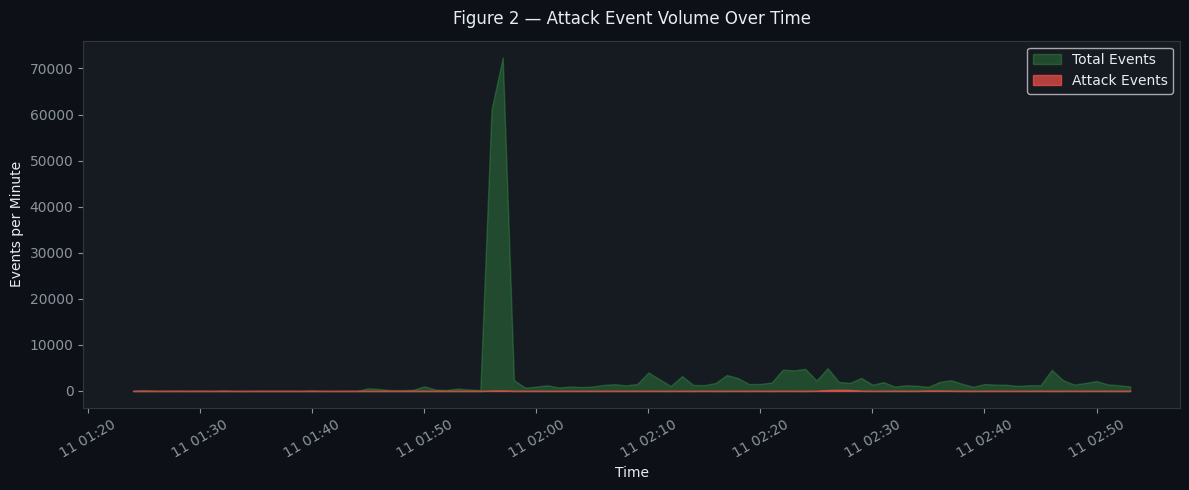

[+] Saved figures/fig2_attack_timeline.png


In [ ]:
# Figure 2 — Attack vs Normal Over Time
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(agg['minute_bucket'], agg['total_events'], alpha=0.3, color=NORMAL_COLOR, label='Total Events')
ax.fill_between(agg['minute_bucket'], agg['attack_events'], alpha=0.7, color=ATTACK_COLOR, label='Attack Events')
ax.set_xlabel('Time')
ax.set_ylabel('Events per Minute')
ax.set_title('Figure 2 — Attack Event Volume Over Time', color='#e6edf3', pad=12)
ax.legend()
plt.xticks(rotation=30)
save_fig('fig2_attack_timeline')

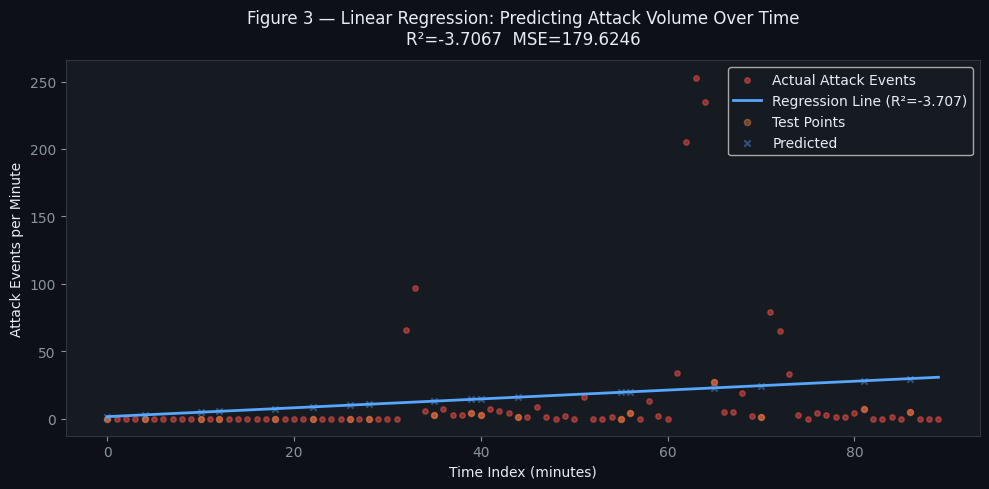

[+] Saved figures/fig3_linear_regression.png


In [ ]:
# Figure 3 — Linear Regression Results
r = results['linear_regression']
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(agg['time_index'], agg['attack_events'], color=ATTACK_COLOR, alpha=0.5, s=15, label='Actual Attack Events')
x_line = np.linspace(agg['time_index'].min(), agg['time_index'].max(), 100).reshape(-1, 1)
y_line = r['model'].predict(x_line)
ax.plot(x_line, y_line, color=ACCENT, linewidth=2, label=f'Regression Line (R²={r["r2"]:.3f})')
ax.scatter(r['X_test'], r['y_test'], color='#f0883e', alpha=0.4, s=20, label='Test Points')
ax.scatter(r['X_test'], r['y_pred'], color=ACCENT, alpha=0.4, s=20, marker='x', label='Predicted')
ax.set_xlabel('Time Index (minutes)')
ax.set_ylabel('Attack Events per Minute')
ax.set_title(f'Figure 3 — Linear Regression: Predicting Attack Volume Over Time\nR²={r["r2"]:.4f}  MSE={r["mse"]:.4f}', color='#e6edf3', pad=12)
ax.legend()
save_fig('fig3_linear_regression')

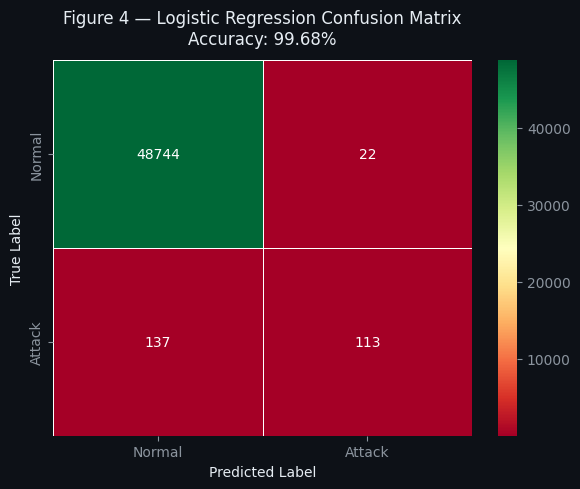

[+] Saved figures/fig4_confusion_logistic.png


In [ ]:
# Figure 4 — Logistic Regression Confusion Matrix
r = results['logistic_regression']
cm = confusion_matrix(r['y_test'], r['y_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Figure 4 — Logistic Regression Confusion Matrix\nAccuracy: {r["accuracy"]*100:.2f}%', color='#e6edf3', pad=12)
save_fig('fig4_confusion_logistic')

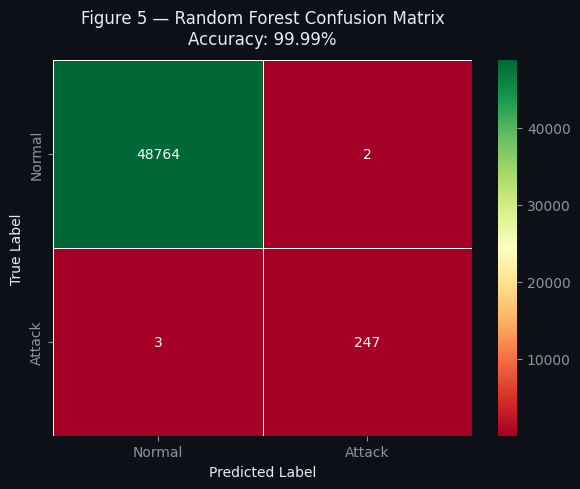

[+] Saved figures/fig5_confusion_rf.png


In [ ]:
# Figure 5 — Random Forest Confusion Matrix
r = results['random_forest']
cm = confusion_matrix(r['y_test'], r['y_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Figure 5 — Random Forest Confusion Matrix\nAccuracy: {r["accuracy"]*100:.2f}%', color='#e6edf3', pad=12)
save_fig('fig5_confusion_rf')

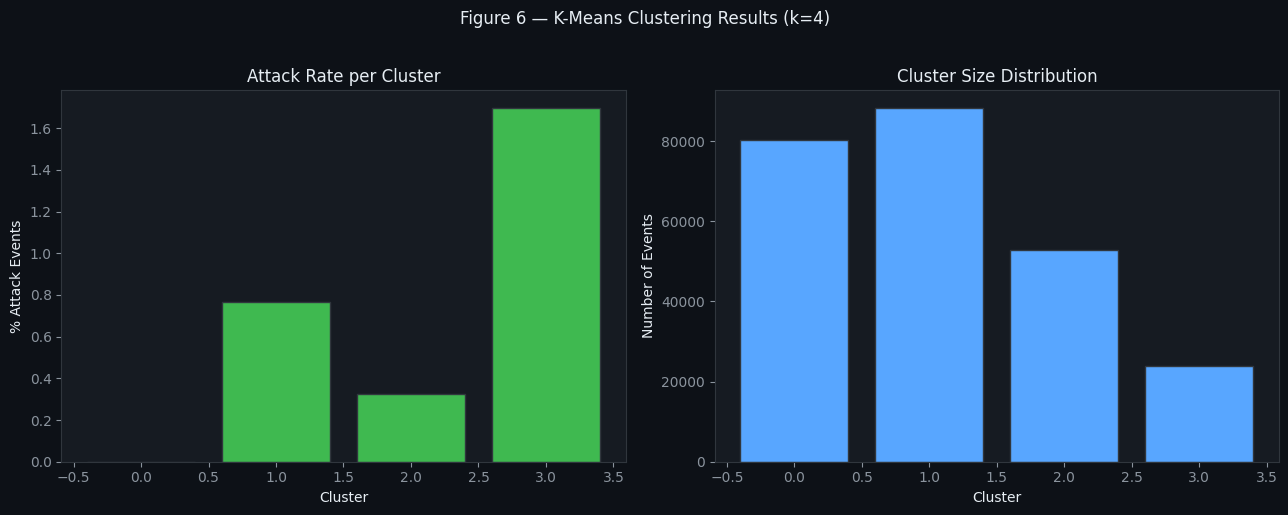

[+] Saved figures/fig6_kmeans.png


In [ ]:
# Figure 6 — K-Means Clustering
df_c = results['kmeans']['df_clustered']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cluster_attack = df_c.groupby('cluster')['is_attack'].mean() * 100
axes[0].bar(cluster_attack.index, cluster_attack.values,
            color=[ATTACK_COLOR if v > 30 else NORMAL_COLOR for v in cluster_attack.values], edgecolor='#30363d')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% Attack Events')
axes[0].set_title('Attack Rate per Cluster', color='#e6edf3')
cluster_size = df_c['cluster'].value_counts().sort_index()
axes[1].bar(cluster_size.index, cluster_size.values, color=ACCENT, edgecolor='#30363d')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Events')
axes[1].set_title('Cluster Size Distribution', color='#e6edf3')
plt.suptitle('Figure 6 — K-Means Clustering Results (k=4)', color='#e6edf3', fontsize=12, y=1.02)
save_fig('fig6_kmeans')

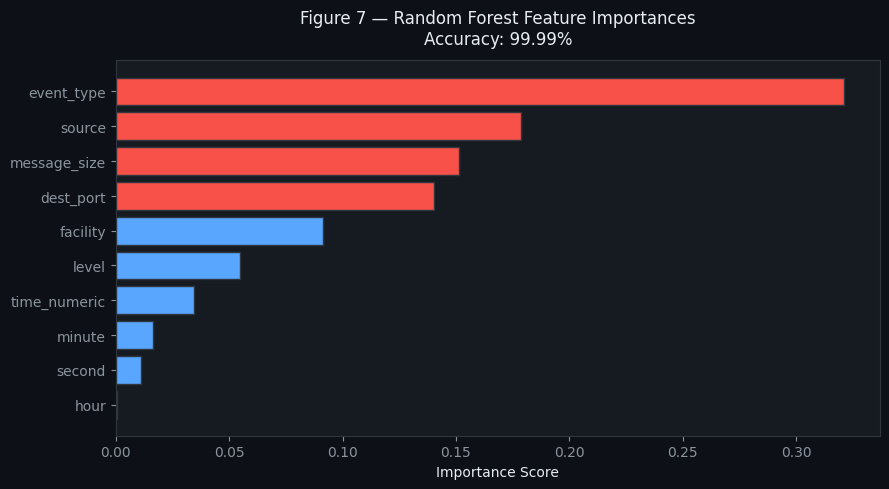

[+] Saved figures/fig7_feature_importance.png


In [ ]:
# Figure 7 — Random Forest Feature Importance
r = results['random_forest']
names = [x[0] for x in r['feature_importances']]
vals = [x[1] for x in r['feature_importances']]
fig, ax = plt.subplots(figsize=(9, 5))
colors = [ATTACK_COLOR if v > 0.1 else ACCENT for v in vals]
ax.barh(names[::-1], vals[::-1], color=colors[::-1], edgecolor='#30363d')
ax.set_xlabel('Importance Score')
ax.set_title(f'Figure 7 — Random Forest Feature Importances\nAccuracy: {r["accuracy"]*100:.2f}%', color='#e6edf3', pad=12)
save_fig('fig7_feature_importance')

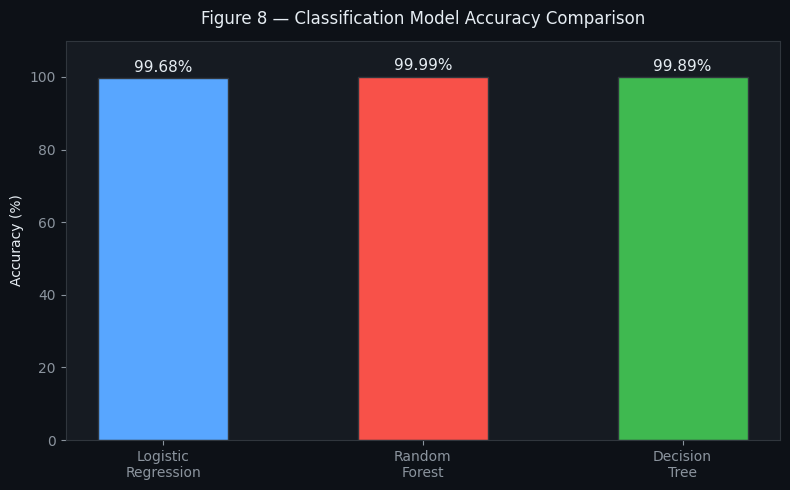

[+] Saved figures/fig8_model_comparison.png


In [ ]:
# Figure 8 — Model Accuracy Comparison
models = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree']
accs = [
    results['logistic_regression']['accuracy'] * 100,
    results['random_forest']['accuracy'] * 100,
    results['decision_tree']['accuracy'] * 100
]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accs, color=[ACCENT, ATTACK_COLOR, NORMAL_COLOR], edgecolor='#30363d', width=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Figure 8 — Classification Model Accuracy Comparison', color='#e6edf3', pad=12)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, color='#e6edf3')
save_fig('fig8_model_comparison')

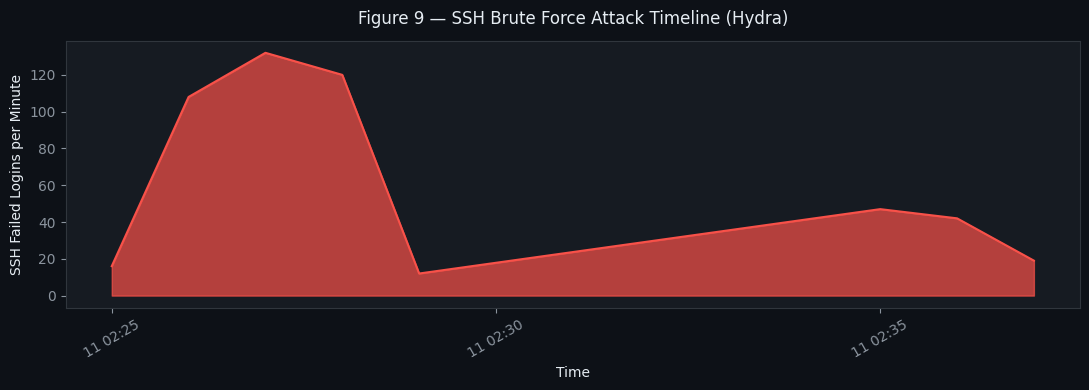

[+] Saved figures/fig9_ssh_timeline.png


In [ ]:
# Figure 9 — SSH Brute Force Timeline
ssh = df[df['event_type'] == 'ssh_failure'].copy()
if len(ssh) == 0:
    print("[!] No SSH failures found for timeline")
else:
    ssh['minute_bucket'] = ssh['timestamp'].dt.floor('1min')
    ssh_counts = ssh.groupby('minute_bucket').size().reset_index(name='count')
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.fill_between(ssh_counts['minute_bucket'], ssh_counts['count'], color=ATTACK_COLOR, alpha=0.7)
    ax.plot(ssh_counts['minute_bucket'], ssh_counts['count'], color=ATTACK_COLOR, linewidth=1.5)
    ax.set_xlabel('Time')
    ax.set_ylabel('SSH Failed Logins per Minute')
    ax.set_title('Figure 9 — SSH Brute Force Attack Timeline (Hydra)', color='#e6edf3', pad=12)
    plt.xticks(rotation=30)
    save_fig('fig9_ssh_timeline')

## Step 6 — Download All Figures

In [ ]:
import zipfile
from google.colab import files

with zipfile.ZipFile('thesis_figures.zip', 'w') as zipf:
    for fname in os.listdir('figures'):
        if fname.endswith('.png'):
            zipf.write(f'figures/{fname}', fname)

print("[+] Downloading thesis_figures.zip...")
files.download('thesis_figures.zip')

[+] Downloading thesis_figures.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>